In [2]:
import tensorflow as tf
import numpy as np

In [3]:
# Define the lyrics of the song
data = "In the town of Athy one Jeremy Lanigan \n Battered away til he hadnt a pound. \nHis father died and made him a man again \n Left him a farm and ten acres of ground. \nHe gave a grand party for friends and relations \nWho didnt forget him when come to the wall, \nAnd if youll but listen Ill make your eyes glisten \nOf the rows and the ructions of Lanigans Ball. \nMyself to be sure got free invitation, \nFor all the nice girls and boys I might ask, \nAnd just in a minute both friends and relations \nWere dancing round merry as bees round a cask. \nJudy ODaly, that nice little milliner, \nShe tipped me a wink for to give her a call, \nAnd I soon arrived with Peggy McGilligan \nJust in time for Lanigans Ball. \nThere were lashings of punch and wine for the ladies, \nPotatoes and cakes; there was bacon and tea, \nThere were the Nolans, Dolans, OGradys \nCourting the girls and dancing away. \nSongs they went round as plenty as water, \nThe harp that once sounded in Taras old hall,\nSweet Nelly Gray and The Rat Catchers Daughter,\nAll singing together at Lanigans Ball. \nThey were doing all kinds of nonsensical polkas \nAll round the room in a whirligig. \nJulia and I, we banished their nonsense \nAnd tipped them the twist of a reel and a jig. \nAch mavrone, how the girls got all mad at me \nDanced til youd think the ceiling would fall. \nFor I spent three weeks at Brooks Academy \nLearning new steps for Lanigans Ball. \nThree long weeks I spent up in Dublin, \nThree long weeks to learn nothing at all,\n Three long weeks I spent up in Dublin, \nLearning new steps for Lanigans Ball. \nShe stepped out and I stepped in again, \nI stepped out and she stepped in again, \nShe stepped out and I stepped in again, \nLearning new steps for Lanigans Ball. \nBoys were all merry and the girls they were hearty \nAnd danced all around in couples and groups, \nTil an accident happened, young Terrance McCarthy \nPut his right leg through miss Finnertys hoops. \nPoor creature fainted and cried Meelia murther, \nCalled for her brothers and gathered them all. \nCarmody swore that hed go no further \nTil he had satisfaction at Lanigans Ball. \nIn the midst of the row miss Kerrigan fainted, \nHer cheeks at the same time as red as a rose. \nSome of the lads declared she was painted, \nShe took a small drop too much, I suppose. \nHer sweetheart, Ned Morgan, so powerful and able, \nWhen he saw his fair colleen stretched out by the wall, \nTore the left leg from under the table \nAnd smashed all the Chaneys at Lanigans Ball. \nBoys, oh boys, twas then there were runctions. \nMyself got a lick from big Phelim McHugh. \nI soon replied to his introduction \nAnd kicked up a terrible hullabaloo. \nOld Casey, the piper, was near being strangled. \nThey squeezed up his pipes, bellows, chanters and all. \nThe girls, in their ribbons, they got all entangled \nAnd that put an end to Lanigans Ball."

# Split the long string per line and put in a list
corpus = data.lower().split("\n")

# Preview the result
print(corpus)

['in the town of athy one jeremy lanigan ', ' battered away til he hadnt a pound. ', 'his father died and made him a man again ', ' left him a farm and ten acres of ground. ', 'he gave a grand party for friends and relations ', 'who didnt forget him when come to the wall, ', 'and if youll but listen ill make your eyes glisten ', 'of the rows and the ructions of lanigans ball. ', 'myself to be sure got free invitation, ', 'for all the nice girls and boys i might ask, ', 'and just in a minute both friends and relations ', 'were dancing round merry as bees round a cask. ', 'judy odaly, that nice little milliner, ', 'she tipped me a wink for to give her a call, ', 'and i soon arrived with peggy mcgilligan ', 'just in time for lanigans ball. ', 'there were lashings of punch and wine for the ladies, ', 'potatoes and cakes; there was bacon and tea, ', 'there were the nolans, dolans, ogradys ', 'courting the girls and dancing away. ', 'songs they went round as plenty as water, ', 'the harp tha

In [4]:
vectorizer = tf.keras.layers.TextVectorization()

vectorizer.adapt(corpus)

In [6]:
vocabulary = vectorizer.get_vocabulary()
vocab_size = len(vocabulary)

print(f'{vocabulary}')
print(f'{vocab_size}')
print(vocab_size)

['', '[UNK]', 'and', 'the', 'a', 'in', 'all', 'i', 'for', 'of', 'lanigans', 'ball', 'were', 'at', 'to', 'stepped', 'she', 'they', 'his', 'girls', 'as', 'weeks', 'up', 'til', 'three', 'there', 'that', 'round', 'out', 'her', 'he', 'got', 'boys', 'again', 'was', 'steps', 'spent', 'new', 'long', 'learning', 'him', 'when', 'wall', 'tipped', 'time', 'them', 'their', 'soon', 'relations', 'put', 'old', 'nice', 'myself', 'miss', 'merry', 'me', 'leg', 'left', 'just', 'from', 'friends', 'fainted', 'dublin', 'dancing', 'danced', 'away', 'an', 'your', 'young', 'youll', 'youd', 'would', 'with', 'wink', 'wine', 'who', 'whirligig', 'went', 'we', 'water', 'under', 'twist', 'twas', 'town', 'tore', 'took', 'too', 'together', 'through', 'think', 'then', 'terrible', 'terrance', 'ten', 'tea', 'taras', 'table', 'swore', 'sweetheart', 'sweet', 'sure', 'suppose', 'stretched', 'strangled', 'squeezed', 'sounded', 'songs', 'some', 'so', 'smashed', 'small', 'singing', 'saw', 'satisfaction', 'same', 'runctions', 'r

In [7]:
input_sequences = []

for line in corpus:
    sequence = vectorizer(line).numpy()
    for i in range(1, len(sequence)):
        n_gram_sequence = sequence[:i+1]
        input_sequences.append(n_gram_sequence)
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(tf.keras.utils.pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))
xs, labels = input_sequences[:,:-1], input_sequences[:,-1]
ys = tf.keras.utils.to_categorical(labels, num_classes=vocab_size)

In [8]:
def sequence_to_text(sequence, vocabulary):
  '''utility to convert integer sequence back to text'''

  # Loop through the integer sequence and look up the word from the vocabulary
  words = [vocabulary[index] for index in sequence]

  # Combine the words into one sentence
  text = tf.strings.reduce_join(words, separator=' ').numpy().decode()

  return text

In [9]:
# Pick element
elem_number = 6

# Print token list and phrase
print(f'token list: {xs[elem_number]}')
print(f'decoded to text: {sequence_to_text(xs[elem_number], vocabulary)}')


token list: [  0   0   0   5   3  83   9 255 140 183]
decoded to text:    in the town of athy one jeremy


In [10]:
# Print label
print(f'one-hot label: {ys[elem_number]}')
print(f'index of label: {np.argmax(ys[elem_number])}')

one-hot label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
index of label: 174


In [11]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(max_sequence_len-1,)),
    tf.keras.layers.Embedding(vocab_size, 64),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 264)            │        34,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,104 (328.53 KB)

 Trainable params: 84,104 (328.53 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(xs, ys, epochs = 100)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8698 - loss: 0.7193 
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8653 - loss: 0.6840
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8521 - loss: 0.6837
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8808 - loss: 0.6361
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8874 - loss: 0.6061
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8985 - loss: 0.5750
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8896 - loss: 0.5574
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8985 - loss: 0.5483
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8631 - loss: 0.6034
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8896 - loss: 0.5680
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8918 - loss: 0.5245
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

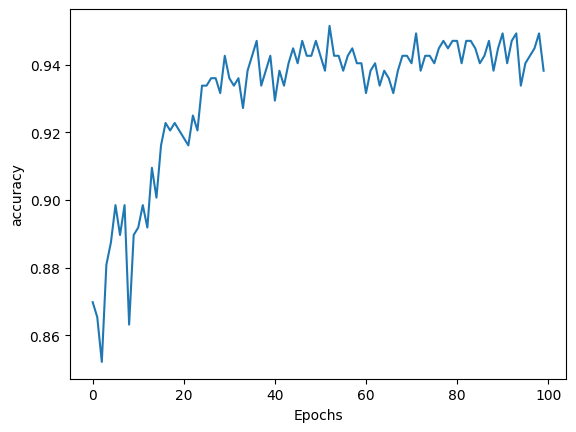

In [16]:
import matplotlib.pyplot as plt

# Plot utility
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.show()

# Visualize the accuracy
plot_graphs(history, 'accuracy')

In [18]:
# Define seed text
seed_text = "Laurence went to Dublin"

# Define total words to predict
next_words = 100

# Loop until desired length is reached
for _ in range(next_words):

	# Convert the seed text to an integer sequence
	sequence = vectorizer(seed_text)

	# Pad the sequence
	sequence = tf.keras.utils.pad_sequences([sequence], maxlen=max_sequence_len-1, padding='pre')

	# Feed to the model and get the probabilities for each index
	probabilities = model.predict(sequence, verbose=0)

	# Get the index with the highest probability
	predicted = np.argmax(probabilities, axis=-1)[0]

	# Ignore if index is 0 because that is just the padding.
	if predicted != 0:

		# Look up the word associated with the index.
		output_word = vocabulary[predicted]

		# Combine with the seed text
		seed_text += " " + output_word

# Print the result
print(seed_text)

Laurence went to Dublin a terrible finnertys hoops hoops hoops eyes glisten glisten glisten glisten water might glisten glisten glisten glisten might ask eyes glisten glisten glisten eyes glisten glisten glisten glisten they were hearty hearty boys were might eyes glisten glisten glisten glisten eyes glisten glisten glisten strangled boys were strangled strangled hearty boys i ask ask might ask ask call call call ask call might ask ask ask ask jig relations her might glisten eyes eyes glisten glisten glisten glisten glisten were strangled strangled strangled boys i ask ask might ask ask call call call ask call might ask ask ask ask


In [20]:
import textwrap

wrapped_text = textwrap.fill(seed_text, width=80)

print(wrapped_text)

Error in callback <function set_css at 0x15be752d0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15bffcfd0, raw_cell="import textwrap

wrapped_text = textwrap.fill(seed.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/aditya/Documents/Github/dl.ai-tensorflow/dl.ai-tensorflow/week4_1.ipynb#X15sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Laurence went to Dublin a terrible finnertys hoops hoops hoops eyes glisten
glisten glisten glisten water might glisten glisten glisten glisten might ask
eyes glisten glisten glisten eyes glisten glisten glisten glisten they were
hearty hearty boys were might eyes glisten glisten glisten glisten eyes glisten
glisten glisten strangled boys were strangled strangled hearty boys i ask ask
might ask ask call call call ask call might ask ask ask ask jig relations her
might glisten eyes eyes glisten glisten glisten glisten glisten were strangled
strangled strangled boys i ask ask might ask ask call call call ask call might
ask ask ask ask


In [24]:
# Define seed text
seed_text = "Laurence went to Dublin"

# Define total words to predict
next_words = 100

# Loop until desired length is reached
for _ in range(next_words):

	# Convert the seed text to an integer sequence
  sequence = vectorizer(seed_text)

	# Pad the sequence
  sequence = tf.keras.utils.pad_sequences([sequence], maxlen=max_sequence_len-1, padding='pre')

	# Feed to the model and get the probabilities for each index
  probabilities = model.predict(sequence, verbose=0)

  # Pick a random number from [1,2,3]
  choice = np.random.choice([1,2,3])

  # Sort the probabilities in ascending order
  # and get the random choice from the end of the array
  predicted = np.argsort(probabilities)[0][-choice]

	# Ignore if index is 0 because that is just the padding.
  if predicted != 0:

    # Look up the word associated with the index.
    output_word = vocabulary[predicted]

    # Combine with the seed text
    seed_text += " " + output_word

# Print the result
wrapped_text = textwrap.fill(seed_text, width=80)

print(wrapped_text)

Error in callback <function set_css at 0x15be752d0> (for pre_run_cell), with arguments args (<ExecutionInfo object at 15c0891b0, raw_cell="# Define seed text
seed_text = "Laurence went to D.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/aditya/Documents/Github/dl.ai-tensorflow/dl.ai-tensorflow/week4_1.ipynb#X21sZmlsZQ%3D%3D>,),kwargs {}:


TypeError: set_css() takes 0 positional arguments but 1 was given

Laurence went to Dublin time the pound whirligig cask whirligig cask a call rose
call your suppose suppose ask might eyes glisten ask eyes eyes glisten eyes
glisten eyes eyes glisten your glisten glisten eyes glisten your eyes your eyes
eyes glisten eyes your eyes glisten your eyes ask glisten eyes eyes your eyes
eyes your ask your glisten glisten eyes your glisten eyes eyes glisten eyes
glisten glisten eyes eyes glisten eyes your glisten glisten your ask glisten
eyes glisten eyes your suppose glisten glisten ask might eyes eyes glisten
glisten ask eyes your your glisten eyes your glisten eyes your ask glisten
